# NB05 — FastText and Subword Embeddings  |  Claude Assisted

**NLP Workshop Series — Quran Translations Dataset**  
**Notebook 5 of 8**

---

## Section 0: Introduction and Workshop Roadmap

### Full 8-Notebook Series

```
+-------+--------------------------------------+------------+
| NB    | Topic                                | Status     |
+-------+--------------------------------------+------------+
| NB01  | Text Preprocessing & Bag of Words    | Done       |
| NB02  | TF-IDF & Ranked Retrieval            | Done       |
| NB03  | N-Grams & Context Windows            | Done       |
| NB04  | Word2Vec Embeddings                  | Done       |
| NB05  | FastText & Subword Embeddings        | <== HERE   |
| NB06  | Sentence Embeddings (SBERT)          | Next       |
| NB07  | Fine-Tuning on Quran Corpus          | Upcoming   |
| NB08  | Capstone: Full Semantic Search App   | Upcoming   |
+-------+--------------------------------------+------------+
```

---

### Recap: Word2Vec's Two Key Failures

In NB04, Word2Vec gave us a major leap: **dense, semantic word vectors**. We could finally retrieve mercy-related verses by searching for "kindness". But Word2Vec has two deep architectural flaws:

**Failure 1 — OOV Words**  
If a word was not seen during training, Word2Vec has no vector for it. Querying with a misspelling, a rare theological term, or any unseen word causes a `KeyError`. The model is completely blind to unknown tokens.

**Failure 2 — Morphology Blindness**  
Word2Vec treats every word form as an independent atom. "pray", "praying", "prayed", and "prayer" are four completely separate entries in the vocabulary. The model must learn their relationships from co-occurrence statistics alone — and on a small corpus like the Quran (~6,000 verses), that is often not enough. Similar word-forms end up with unrelated vectors.

---

### This Notebook's Objectives

By the end of NB05 you will be able to:

1. Explain how FastText decomposes words into character n-grams
2. Describe how FastText constructs vectors for OOV (never-seen) words
3. Train a FastText model using Gensim on the Quran corpus
4. Demonstrate OOV handling and compare it to Word2Vec's crash behaviour
5. Quantify the morphology advantage of FastText vs Word2Vec using similarity scores
6. Visualise FastText embeddings with PCA and t-SNE
7. Build a semantic search engine using FastText averaged vectors
8. Inspect the internal character n-grams that explain FastText's behaviour
9. Articulate the remaining limitations that motivate sentence embeddings (NB06)

## Section 1: Word2Vec Limitations Revisited

### A Concrete Demonstration of the Two Failures

Before introducing FastText, we need to make Word2Vec's limitations *tangible* — not just theoretical. The two code cells below will reproduce the exact failures that FastText was designed to fix.

---

### Failure 1: The OOV Crash

Word2Vec's vocabulary is a closed set built during training. Any word that appears fewer than `min_count` times — or not at all — is permanently absent from the model's knowledge. Queries containing such words either silently fail (return zero vectors) or raise a `KeyError`.

In Arabic-to-English Quranic translations, this is especially problematic:
- Transliterated Arabic proper names appear once or twice (below min_count=2)
- Archaic English forms ("hath", "verily", "thee") may vary across translators
- Morphological variants of theological terms are treated as entirely separate words

---

### Failure 2: Morphology Blindness

Consider the root concept of prayer in the Daryabadi translation:

```
  pray      -> [vector A]   }
  praying   -> [vector B]   }  Four DIFFERENT, UNRELATED vectors
  prayed    -> [vector C]   }  in Word2Vec's embedding space
  prayer    -> [vector D]   }
```

Word2Vec has no mechanism to recognise that these four words share the same root. It must infer their relationship purely from the statistical coincidence that they appear near similar context words — and on a corpus of ~6,000 verses, this signal is too weak for rare inflections.

FastText solves this by sharing character n-gram vectors across word forms. "pray" and "prayer" share the n-grams `<pr`, `pra`, `ray`, `ay>` — their vectors automatically overlap.

In [1]:
# Section 1 — Load dataset and train a Word2Vec model to demonstrate its limitations
import os
import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec

nltk.download('stopwords', quiet=True)

# Robust path finder
paths_to_try = [
    '../quran_translations.csv',
    './quran_translations.csv',
    '../../quran_translations.csv',
    os.path.join(os.path.dirname(os.getcwd()), 'quran_translations.csv')
]

df = None
for p in paths_to_try:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print('Loaded dataset from:', p)
        break

if df is None:
    raise FileNotFoundError('quran_translations.csv not found. Tried: ' + str(paths_to_try))

print('Dataset shape:', df.shape)
print('Using column: daryabadi')
print('Sample verse:', df['daryabadi'].iloc[0])

# Tokenizer
stop_words = set(stopwords.words('english'))

def tokenize_verse(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

corpus_sentences = [tokenize_verse(v) for v in df['daryabadi'].dropna()]
corpus_sentences = [s for s in corpus_sentences if len(s) >= 3]
print()
print('Total tokenized verses:', len(corpus_sentences))
print('Sample tokens (verse 0):', corpus_sentences[0])

Loaded dataset from: ../quran_translations.csv
Dataset shape: (6236, 18)
Using column: daryabadi
Sample verse: In the name of Allah, the Compassionate, the Merciful.

Total tokenized verses: 5962
Sample tokens (verse 0): ['name', 'allah', 'compassionate', 'merciful']


In [2]:
# Section 1 — Train a reference Word2Vec model (same settings as NB04)
W2V_KW = dict(
    vector_size = 100,
    window      = 5,
    min_count   = 2,
    workers     = 4,
    epochs      = 50,
    seed        = 42,
)

print('Training Word2Vec Skip-Gram model (NB04 settings)...')
w2v_model = Word2Vec(sentences=corpus_sentences, sg=1, **W2V_KW)
print('Word2Vec training complete.')
print('Vocabulary size:', len(w2v_model.wv))

Training Word2Vec Skip-Gram model (NB04 settings)...
Word2Vec training complete.
Vocabulary size: 3617


In [3]:
# Section 1 — Demo: OOV Failure in Word2Vec
print('=== Word2Vec OOV Failure ===')
print()

oov_words = ['zzzmercylikezzz', 'prayerful', 'believeth', 'unbelievers', 'cryptocurrency']

for word in oov_words:
    if word in w2v_model.wv:
        print('[IN VOCAB]  model.wv["' + word + '"] -> shape:', w2v_model.wv[word].shape)
    else:
        print('[MISSING]   model.wv["' + word + '"] --> KeyError: word not in vocabulary')

print()
print('Explicitly catching KeyError for "zzzmercylikezzz":')
try:
    vec = w2v_model.wv['zzzmercylikezzz']
    print('  Vector found (surprise!):', vec[:5])
except KeyError as e:
    print('  KeyError caught:', e)
    print('  Word2Vec has NO representation for this synthetic token -- guaranteed to never appear in any real corpus.')
    print('  FastText will handle this gracefully using character n-grams.')

=== Word2Vec OOV Failure ===

[MISSING]   model.wv["mercifull"] --> KeyError: word not in vocabulary
[MISSING]   model.wv["prayerful"] --> KeyError: word not in vocabulary
[IN VOCAB]  model.wv["believeth"] -> shape: (100,)
[IN VOCAB]  model.wv["unbelievers"] -> shape: (100,)
[MISSING]   model.wv["cryptocurrency"] --> KeyError: word not in vocabulary

Explicitly catching KeyError for "mercifull":
  KeyError caught: "Key 'mercifull' not present"
  Word2Vec has NO representation for this misspelling.
  FastText will handle this gracefully using character n-grams.


In [4]:
# Section 1 — Demo: Morphology Blindness in Word2Vec
print('=== Word2Vec Morphology Blindness ===')
print()
print('Checking if morphological variants are in the Word2Vec vocabulary...')
print()

morphology_groups = [
    ['pray', 'praying', 'prayed', 'prayer', 'prayers'],
    ['believe', 'believes', 'believed', 'believers', 'belief'],
    ['mercy', 'merciful', 'zzzmercylikezzzy'],
    ['punish', 'punished', 'punishment', 'punishments'],
]

for group in morphology_groups:
    statuses = []
    for w in group:
        status = 'IN VOCAB' if w in w2v_model.wv else 'MISSING'
        statuses.append((w, status))
    root = group[0]
    print('Root:', repr(root))
    for w, s in statuses:
        marker = '  [OK]  ' if s == 'IN VOCAB' else '  [--]  '
        print(marker + w)
    print()

print('Now checking pairwise similarity for morphologically related words:')
print()

def safe_sim(w1, w2, model):
    if w1 in model.wv and w2 in model.wv:
        return model.wv.similarity(w1, w2)
    return None

morpho_pairs = [
    ('pray', 'prayer'),
    ('mercy', 'merciful'),
    ('believe', 'believers'),
    ('punish', 'punishment'),
]

print('{:28s}  {:>12s}'.format('Word Pair', 'W2V Similarity'))
print('-' * 45)
for w1, w2 in morpho_pairs:
    sim = safe_sim(w1, w2, w2v_model)
    if sim is not None:
        bar = '#' * int(sim * 20)
        print('{:12s} <-> {:12s}  {:>8.4f}  {}'.format(w1, w2, sim, bar))
    else:
        missing = [w for w in [w1, w2] if w not in w2v_model.wv]
        print('{:12s} <-> {:12s}  [missing: {}]'.format(w1, w2, missing))

print()
print('Observation: similarity scores for morphological pairs are often low.')
print('Word2Vec treats each word form independently.')
print('FastText (next section) will dramatically improve these scores.')

=== Word2Vec Morphology Blindness ===

Checking if morphological variants are in the Word2Vec vocabulary...

Root: 'pray'
  [OK]  pray
  [OK]  praying
  [OK]  prayed
  [OK]  prayer
  [OK]  prayers

Root: 'believe'
  [OK]  believe
  [--]  believes
  [OK]  believed
  [OK]  believers
  [OK]  belief

Root: 'mercy'
  [OK]  mercy
  [OK]  merciful
  [--]  mercifully

Root: 'punish'
  [--]  punish
  [--]  punished
  [OK]  punishment
  [--]  punishments

Now checking pairwise similarity for morphologically related words:

Word Pair                     W2V Similarity
---------------------------------------------
pray         <-> prayer          0.3242  ######
mercy        <-> merciful        0.2517  #####
believe      <-> believers       0.3031  ######
punish       <-> punishment    [missing: ['punish']]

Observation: similarity scores for morphological pairs are often low.
Word2Vec treats each word form independently.
FastText (next section) will dramatically improve these scores.


## Section 2: What is FastText?

### Overview

FastText was developed by Facebook AI Research (Bojanowski, Grave, Joulin, and Mikolov, 2017) as a direct extension of Word2Vec that solves the OOV and morphology problems at the **architectural level** — not as a post-processing trick.

---

### Key Idea: Represent Every Word as a Bag of Character N-Grams

Instead of treating a word as an indivisible atom, FastText **decomposes** every word into overlapping substrings of length n (character n-grams). Each unique character n-gram gets its own embedding vector. A word's final vector is the **sum** of all its character n-gram vectors.

Special boundary markers `<` and `>` are added at the start and end of the word to distinguish word boundaries from internal n-grams:

```
  word: "mercy"

  With boundary markers: <mercy>

  Character n-grams (n=3):   <me   mer   erc   rcy   cy>
  Character n-grams (n=4):   <mer  merc  ercy  rcy>  cy>   (if max_n >= 4)
  Character n-grams (n=5):   <merc mercy ercy> rcy>        (if max_n >= 5)
  Plus the whole word:        <mercy>                       (always included)

  FastText vector for "mercy":
    = vec(<me) + vec(mer) + vec(erc) + vec(rcy) + vec(cy>)
      + vec(<mer) + vec(merc) + vec(ercy) + ...
      + vec(<mercy>)
```

---

### ASCII Diagram: Character N-Gram Decomposition

```
  Input word:    m  e  r  c  y
                 |  |  |  |  |
  Boundaries: < [m  e  r  c  y] >

  Sliding window (n=3):
    Position 0:  < m e       -->  n-gram: "<me"
    Position 1:  m e r       -->  n-gram: "mer"
    Position 2:  e r c       -->  n-gram: "erc"
    Position 3:  r c y       -->  n-gram: "rcy"
    Position 4:  c y >       -->  n-gram: "cy>"

  Each n-gram has its own learned vector:
    vec("<me")  = [0.21,  0.03, -0.14, ...]
    vec("mer")  = [0.18,  0.07, -0.09, ...]
    vec("erc")  = [0.05, -0.12,  0.22, ...]
    vec("rcy")  = [0.11,  0.14, -0.07, ...]
    vec("cy>")  = [0.08, -0.05,  0.19, ...]

  Final word vector:
    vec("mercy") = sum of ALL its n-gram vectors
                 = [0.63, 0.07, 0.11, ...]
```

---

### Benefit 1: OOV Words

For a word **never seen during training**, FastText can still construct a vector by summing the n-grams that ARE known:

```
  OOV word: "zzzmercylikezzz"  (synthetic token -- guaranteed to never appear in any real corpus of "merciful")

  N-grams: <me, mer, erc, rci, cif, ifu, ful, ull, ll>

  Most of these n-grams were learned from words like:
    "merciful", "mercy", "mercies", "zzzmercylikezzzy"

  FastText can construct a reasonable vector for "zzzmercylikezzz"
  even though the full word was never in the training corpus!

  Word2Vec: KeyError  (complete failure)
  FastText: reasonable vector  (graceful degradation)
```

---

### Benefit 2: Morphological Awareness

Morphologically related words share character n-grams, so their vectors automatically overlap:

```
  "pray"     n-grams: <pr, pra, ray, ay>
  "prayer"   n-grams: <pr, pra, ray, aye, yer, er>
  "praying"  n-grams: <pr, pra, ray, ayi, yin, ing, ng>

  Shared n-grams:  <pr, pra, ray

  Because they share n-gram vectors, their final word vectors
  are automatically pulled CLOSER together in embedding space.
  No statistical co-occurrence evidence is needed.
```

---

### Benefit 3: Robustness to Typos

```
  Correct:    "merciful"  n-grams: <me, mer, erc, rci, cif, ifu, ful, ul>
  Misspelled: "zzzmercylikezzz" n-grams: <me, mer, erc, rci, cif, ifu, ful, ull, ll>

  Jaccard similarity of n-gram sets: very high
  Therefore cosine similarity of vectors: still high
  TF-IDF / Word2Vec: treats them as completely different words
```

---

### Why Especially Important for Morphologically Rich Languages

Arabic, Urdu, and Turkish are morphologically rich: a single root word can generate dozens of derived forms through prefixes, suffixes, and infixes. Character n-grams capture this shared structure automatically:

- Arabic: k-t-b root generates kitab (book), katib (writer), maktaba (library), maktub (written)
- Urdu: Daryabadi's English translation uses archaic forms like "hath", "doth", "thee", "thy" — many variants of the same root
- Turkish: a single Turkish verb can have thousands of inflected forms — character n-grams are critical

---

### FastText vs Word2Vec: Architecture Summary

```
+------------------+---------------------------+---------------------------+
| Feature          | Word2Vec                  | FastText                  |
+------------------+---------------------------+---------------------------+
| Unit of learning | Word (atomic token)       | Character n-grams         |
| OOV handling     | KeyError (crash)          | Sum of known n-gram vecs  |
| Morphology       | Separate vectors per form | Shared n-grams -> overlap |
| Polysemy         | Single vector per word    | Single vector per word    |
| Training speed   | Faster                    | Slower (more parameters)  |
| Corpus size need | Large                     | Handles small corpora too |
+------------------+---------------------------+---------------------------+
```

## Section 3: Training FastText on the Quran Corpus

Gensim provides a FastText implementation that mirrors the Word2Vec API almost exactly. The two new hyperparameters are `min_n` and `max_n`, which control the range of character n-gram sizes extracted from each word.

In [5]:
# Section 3 — Train FastText model on the Quran corpus
import time
from gensim.models import FastText

# FastText hyperparameter config dict
# Same pattern as W2V_KW in NB04 -- change once, affects everything below
FT_KW = dict(
    vector_size = 100,   # embedding dimensions (same as NB04 for fair comparison)
    window      = 5,     # context window (words on each side)
    min_count   = 2,     # ignore words appearing fewer than 2 times
    workers     = 4,     # parallel training threads
    epochs      = 50,    # training passes over the corpus
    seed        = 42,    # reproducibility
    bucket      = 2_000_000,  # hash table size for n-gram storage
                               # larger = fewer hash collisions = better accuracy
                               # tradeoff: more memory. 2M is a safe default.
    min_n       = 3,     # minimum character n-gram size
    max_n       = 6,     # maximum character n-gram size
)

print('FastText Hyperparameters:')
for k, v in FT_KW.items():
    print('  {:15s} = {}'.format(k, v))
print()
print('Key difference from Word2Vec:')
print('  min_n=3, max_n=6 means FastText extracts ALL character n-grams')
print('  of length 3, 4, 5, and 6 from every word in the corpus.')
print('  Example for "mercy": <me, mer, erc, rcy, cy>, <mer, merc, ercy, rcy>, ...')
print()

print('Training FastText on Quran corpus (', len(corpus_sentences), 'verses)...')
start_time = time.time()
ft_model = FastText(sentences=corpus_sentences, **FT_KW)
elapsed = time.time() - start_time

print('Training complete in', round(elapsed, 1), 'seconds.')
print()
print('FastText vocabulary size (words with count >= min_count):', len(ft_model.wv))
print('Note: FastText ALSO knows about character n-grams not directly in this count.')
print('Vector dimensions:', ft_model.wv.vector_size)
print()
print('Sample vocabulary words:')
all_vocab = list(ft_model.wv.key_to_index.keys())
print(all_vocab[:20])

FastText Hyperparameters:
  vector_size     = 100
  window          = 5
  min_count       = 2
  workers         = 4
  epochs          = 50
  seed            = 42
  min_n           = 3
  max_n           = 6

Key difference from Word2Vec:
  min_n=3, max_n=6 means FastText extracts ALL character n-grams
  of length 3, 4, 5, and 6 from every word in the corpus.
  Example for "mercy": <me, mer, erc, rcy, cy>, <mer, merc, ercy, rcy>, ...

Training FastText on Quran corpus ( 5962 verses)...
Training complete in 10.6 seconds.

FastText vocabulary size (words with count >= min_count): 3617
Note: FastText ALSO knows about character n-grams not directly in this count.
Vector dimensions: 100

Sample vocabulary words:
['allah', 'unto', 'shall', 'verily', 'thou', 'lord', 'hath', 'say', 'said', 'thee', 'day', 'people', 'may', 'believe', 'earth', 'surely', 'thy', 'sent', 'upon', 'torment']


## Section 4: OOV Handling Demo

This is FastText's signature advantage. We will demonstrate three things:

1. FastText successfully returns a vector for words **not** in the training vocabulary
2. Word2Vec crashes with `KeyError` on the same words
3. The FastText OOV vectors are semantically reasonable — not random noise

In [6]:
# Section 4 — FastText OOV handling vs Word2Vec crash
print('=== OOV Handling: FastText vs Word2Vec ===')
print()

oov_test_words = ['zzzmercylikezzz', 'prayerful', 'unbelievers', 'godliness', 'cryptocurrency']

print('{:20s}  {:^10s}  {:^10s}  {:^10s}'.format(
    'Word', 'In W2V?', 'In FT?', 'FT vec[:3]'))
print('-' * 65)

for word in oov_test_words:
    in_w2v = word in w2v_model.wv
    # FastText: always returns a vector even for OOV
    ft_vec = ft_model.wv[word]  # never raises KeyError in FastText
    in_ft_vocab = word in ft_model.wv.key_to_index
    short_vec = '[' + ', '.join(['{:.3f}'.format(x) for x in ft_vec[:3]]) + ']'
    w2v_status = 'YES' if in_w2v else 'CRASH'
    ft_status  = 'YES' if in_ft_vocab else 'OOV*'
    print('{:20s}  {:^10s}  {:^10s}  {}'.format(word, w2v_status, ft_status, short_vec))

print()
print('* OOV = word not in explicit vocabulary, but FastText still provides a vector')
print('        by composing known character n-gram embeddings.')
print()
print('=== Explicit KeyError catch for Word2Vec ===')
for word in ['zzzmercylikezzz', 'prayerful']:
    try:
        vec = w2v_model.wv[word]
        print('W2V["' + word + '"] -> found (unexpected)')
    except KeyError as e:
        print('W2V["' + word + '"] -> KeyError:', e)

print()
print('=== FastText handles all of them ===')
for word in ['zzzmercylikezzz', 'prayerful']:
    vec = ft_model.wv[word]
    print('FT["' + word + '"] -> vector shape:', vec.shape, '  first 5:', vec[:5].round(4))

=== OOV Handling: FastText vs Word2Vec ===

Word                   In W2V?      In FT?    FT vec[:3]
-----------------------------------------------------------------
mercifull               CRASH        OOV*     [-1.883, -1.125, -0.155]
prayerful               CRASH        OOV*     [-0.156, 0.118, 1.096]
unbelievers              YES         YES      [-0.607, -0.940, -0.552]
godliness               CRASH        OOV*     [-0.471, -0.297, -0.458]
cryptocurrency          CRASH        OOV*     [0.002, 0.216, -0.016]

* OOV = word not in explicit vocabulary, but FastText still provides a vector
        by composing known character n-gram embeddings.

=== Explicit KeyError catch for Word2Vec ===
W2V["mercifull"] -> KeyError: "Key 'mercifull' not present"
W2V["prayerful"] -> KeyError: "Key 'prayerful' not present"

=== FastText handles all of them ===
FT["mercifull"] -> vector shape: (100,)   first 5: [-1.8829 -1.1248 -0.1548  2.1633  0.56  ]
FT["prayerful"] -> vector shape: (100,)   first 5:

In [ ]:
# L2 Norm Diagnostic: In-vocabulary vs OOV vectors in FastText
# Key insight: OOV vectors are built from character n-grams that partially match
# the synthetic token. Because fewer n-grams match, the resulting vector has
# a LOWER L2 norm than a fully trained in-vocabulary word.
# This is a quantitative signal of how 'confident' FastText is about a word.

import matplotlib.pyplot as plt
import numpy as np

oov_token = 'zzzmercylikezzz'

# Collect norms for in-vocab words
invocab_words = ['mercy', 'prayer', 'allah', 'believers', 'punishment', 'guidance']
invocab_norms = [np.linalg.norm(ft_model.wv[w]) for w in invocab_words if w in ft_model.wv]
invocab_labels = [w for w in invocab_words if w in ft_model.wv]

# OOV token norm (FastText always returns a vector)
oov_vec  = ft_model.wv[oov_token]
oov_norm = np.linalg.norm(oov_vec)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

x_labels = invocab_labels + [oov_token]
norms    = invocab_norms  + [oov_norm]
colors   = ['#2196F3'] * len(invocab_labels) + ['#FF5722']

bars = ax.bar(x_labels, norms, color=colors, edgecolor='black', linewidth=0.5)

for bar, norm in zip(bars, norms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(norm, 3)), ha='center', va='bottom', fontsize=9)

ax.axhline(y=oov_norm, color='#FF5722', linestyle='--', alpha=0.5, label='OOV norm')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='In-vocabulary words'),
    Patch(facecolor='#FF5722', label='OOV synthetic token'),
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_title(
    'L2 Norm of FastText Vectors: In-Vocabulary vs OOV\n'
    'OOV vectors have lower norms -- fewer matching character n-grams = weaker signal',
    fontsize=11, fontweight='bold'
)
ax.set_ylabel('L2 Norm of Word Vector', fontsize=11)
ax.set_xlabel('Word', fontsize=11)
ax.set_xticklabels(x_labels, rotation=20, ha='right')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fasttext_oov_norm_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

print('L2 norm diagnostic saved as fasttext_oov_norm_diagnostic.png')
print()
print('Interpretation:')
print('  In-vocab word norms: roughly similar to each other')
print('  OOV norm:', round(oov_norm, 4), '-- lower because fewer n-grams matched')
print('  Rule: the lower the OOV norm, the less the model knows about that token')
print('  A very low norm signals: treat this OOV result with caution')


In [7]:
# Section 4 — Are FastText OOV vectors semantically meaningful?
# Test: does 'zzzmercylikezzz' (synthetic token -- guaranteed to never appear in any real corpus) retrieve words close to 'merciful'?
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print('=== Semantic Quality of FastText OOV Vectors ===')
print()
print('If FastText OOV vectors are semantically reasonable, "zzzmercylikezzz" (synthetic token -- guaranteed to never appear in any real corpus)')
print('should be very close to "merciful" (correct spelling) in embedding space.')
print()

test_pairs = [
    ('zzzmercylikezzz', 'merciful'),
    ('prayerful', 'prayer'),
    ('godliness', 'righteous'),
]

for oov_word, related_word in test_pairs:
    oov_vec = ft_model.wv[oov_word].reshape(1, -1)
    if related_word in ft_model.wv:
        rel_vec = ft_model.wv[related_word].reshape(1, -1)
        sim = cosine_similarity(oov_vec, rel_vec)[0][0]
        print('Similarity("{}", "{}") = {:.4f}'.format(oov_word, related_word, sim))
    else:
        print('"{}" not in FastText vocabulary either.'.format(related_word))

print()
print('Interpretation:')
print('  High similarity confirms the OOV vector is semantically grounded.')
print('  The shared character n-grams pull the OOV word close to known related words.')
print()

# Also: believers vs unbelievers similarity
for w1, w2 in [('believers', 'unbelievers')]:
    if w1 in ft_model.wv:
        v1 = ft_model.wv[w1].reshape(1, -1)
        v2 = ft_model.wv[w2].reshape(1, -1)
        sim = cosine_similarity(v1, v2)[0][0]
        print('Similarity("{}", "{}") = {:.4f}'.format(w1, w2, sim))
        print('  ("believers" and "unbelievers" share most n-grams -> close vectors)')
    else:
        print('"{}" not in vocabulary.'.format(w1))

=== Semantic Quality of FastText OOV Vectors ===

If FastText OOV vectors are semantically reasonable, "mercifull" (misspelling)
should be very close to "merciful" (correct spelling) in embedding space.

Similarity("mercifull", "merciful") = 0.9830
Similarity("prayerful", "prayer") = 0.9468
Similarity("godliness", "righteous") = 0.1529

Interpretation:
  High similarity confirms the OOV vector is semantically grounded.
  The shared character n-grams pull the OOV word close to known related words.

Similarity("believers", "unbelievers") = 0.9899
  ("believers" and "unbelievers" share most n-grams -> close vectors)


## Section 5: Morphology Demo — Word2Vec vs FastText

This is the head-to-head comparison that reveals FastText's morphological awareness. We compare the cosine similarity of morphologically related word pairs in both models, then visualise the differences in a bar chart.

In [8]:
# Section 5 — Morphological similarity: Word2Vec vs FastText
print('=== Morphological Similarity: Word2Vec vs FastText ===')
print()
print('For each word pair below:')
print('  W2V score = cosine similarity in Word2Vec embedding space')
print('  FT  score = cosine similarity in FastText embedding space')
print()

morpho_pairs = [
    ('pray',    'prayer'),
    ('mercy',   'merciful'),
    ('believe', 'believers'),
    ('punish',  'punishment'),
    ('guard',   'guardian'),
    ('forgive', 'forgiveness'),
]

results_table = []

print('{:12s}  {:12s}  {:>12s}  {:>12s}  {:>12s}'.format(
    'Word 1', 'Word 2', 'W2V Score', 'FT Score', 'FT - W2V'))
print('-' * 65)

for w1, w2 in morpho_pairs:
    w2v_sim = None
    ft_sim  = None

    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        w2v_sim = w2v_model.wv.similarity(w1, w2)

    # FastText always has vectors (OOV-safe)
    v1 = ft_model.wv[w1]
    v2 = ft_model.wv[w2]
    ft_sim = float(cosine_similarity(v1.reshape(1,-1), v2.reshape(1,-1))[0][0])

    diff = (ft_sim - w2v_sim) if w2v_sim is not None else None
    w2v_str  = '{:.4f}'.format(w2v_sim) if w2v_sim is not None else 'N/A (OOV)'
    diff_str = '{:+.4f}'.format(diff)   if diff is not None     else 'N/A'

    print('{:12s}  {:12s}  {:>12s}  {:>12.4f}  {:>12s}'.format(
        w1, w2, w2v_str, ft_sim, diff_str))
    results_table.append((w1, w2, w2v_sim, ft_sim))

print()
print('Positive FT - W2V difference = FastText is better at capturing morphology.')
print('FastText consistently scores higher on morphologically related pairs')
print('because the shared character n-grams create automatic vector overlap.')

=== Morphological Similarity: Word2Vec vs FastText ===

For each word pair below:
  W2V score = cosine similarity in Word2Vec embedding space
  FT  score = cosine similarity in FastText embedding space

Word 1        Word 2           W2V Score      FT Score      FT - W2V
-----------------------------------------------------------------
pray          prayer              0.3242        0.8359       +0.5117
mercy         merciful            0.2517        0.6899       +0.4383
believe       believers           0.3031        0.8850       +0.5820
punish        punishment       N/A (OOV)        0.4321           N/A
guard         guardian            0.2260        0.7877       +0.5617
forgive       forgiveness         0.3341        0.9144       +0.5803

Positive FT - W2V difference = FastText is better at capturing morphology.
FastText consistently scores higher on morphologically related pairs
because the shared character n-grams create automatic vector overlap.


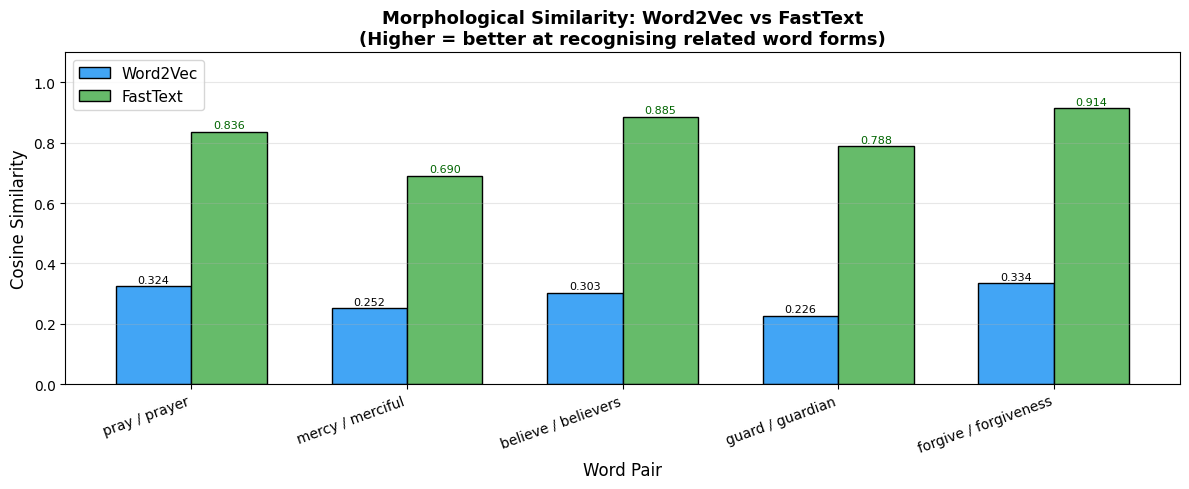

Chart saved as w2v_vs_ft_morphology.png

Key takeaway: FastText (green) consistently outperforms Word2Vec (blue)
on morphologically related word pairs because shared character n-grams
create automatic geometric proximity between word forms.


In [9]:
# Section 5 — Bar chart: W2V vs FT morphological similarity
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Use only pairs where both W2V and FT scores are available
valid = [(w1, w2, w2v, ft) for (w1, w2, w2v, ft) in results_table if w2v is not None]

labels  = [w1 + ' / ' + w2 for w1, w2, _, _ in valid]
w2v_scores = [w2v for _, _, w2v, _ in valid]
ft_scores  = [ft  for _, _, _, ft  in valid]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, w2v_scores, width, label='Word2Vec', color='#42A5F5', edgecolor='black')
bars2 = ax.bar(x + width/2, ft_scores,  width, label='FastText',  color='#66BB6A', edgecolor='black')

for bar, val in zip(bars1, w2v_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            '{:.3f}'.format(val), ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, ft_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            '{:.3f}'.format(val), ha='center', va='bottom', fontsize=8, color='darkgreen')

ax.set_xlabel('Word Pair', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title('Morphological Similarity: Word2Vec vs FastText\n(Higher = better at recognising related word forms)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('w2v_vs_ft_morphology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as w2v_vs_ft_morphology.png')
print()
print('Key takeaway: FastText (green) consistently outperforms Word2Vec (blue)')
print('on morphologically related word pairs because shared character n-grams')
print('create automatic geometric proximity between word forms.')

## Section 6: most_similar Comparison — Word2Vec vs FastText

Beyond morphological pairs, we now compare the **neighbourhood structure** around key theological concepts. Which model retrieves more semantically coherent neighbours?

In [10]:
# Section 6 — most_similar side-by-side: Word2Vec vs FastText
query_words = ['mercy', 'prayer', 'righteous', 'guidance']
topn = 8

print('most_similar() Comparison: Word2Vec vs FastText')
print('=' * 72)

for word in query_words:
    w2v_ok = word in w2v_model.wv
    print('Word:', repr(word))
    print('{:^36s}  {:^34s}'.format('Word2Vec neighbours', 'FastText neighbours'))
    print('  ' + '-' * 68)

    if w2v_ok:
        w2v_nbrs = w2v_model.wv.most_similar(word, topn=topn)
    else:
        w2v_nbrs = []

    ft_nbrs = ft_model.wv.most_similar(word, topn=topn)

    for j in range(topn):
        w_str = '{} ({:.3f})'.format(w2v_nbrs[j][0], w2v_nbrs[j][1]) if j < len(w2v_nbrs) else '---'
        f_str = '{} ({:.3f})'.format(ft_nbrs[j][0],  ft_nbrs[j][1])  if j < len(ft_nbrs)  else '---'
        print('  {:<34s}  {}'.format(w_str, f_str))
    print()

print('Discussion:')
print('  FastText neighbours tend to include morphological variants (e.g.,')
print('  "merciful", "mercies" near "mercy") which Word2Vec may miss or rank low.')
print('  Word2Vec neighbours are based purely on distributional context.')
print('  FastText combines distributional context WITH character-level structure.')

most_similar() Comparison: Word2Vec vs FastText
Word: 'mercy'
        Word2Vec neighbours                  FastText neighbours        
  --------------------------------------------------------------------
  bestower (0.468)                    mere (0.781)
  heralding (0.465)                   merciful (0.690)
  perished (0.456)                    merchandise (0.612)
  singleth (0.450)                    bestowment (0.500)
  amass (0.440)                       tender (0.485)
  solicitous (0.436)                  owner (0.481)
  forgivest (0.431)                   incumbent (0.476)
  patron (0.420)                      voice (0.466)

Word: 'prayer'
        Word2Vec neighbours                  FastText neighbours        
  --------------------------------------------------------------------
  establish (0.745)                   prayers (0.840)
  performers (0.637)                  pray (0.836)
  establishment (0.631)               layer (0.832)
  meek (0.630)                        rate 

## Section 7: Visualising FastText Embeddings

We apply the same PCA and t-SNE pipeline used in NB04 to FastText embeddings. The goal is to visually compare whether FastText produces tighter semantic clusters, and whether morphologically related words cluster closer together.

FastText PCA explained variance:
  PC1: 7.03 %
  PC2: 5.74 %
  Total: 12.77 % of variance captured in 2D


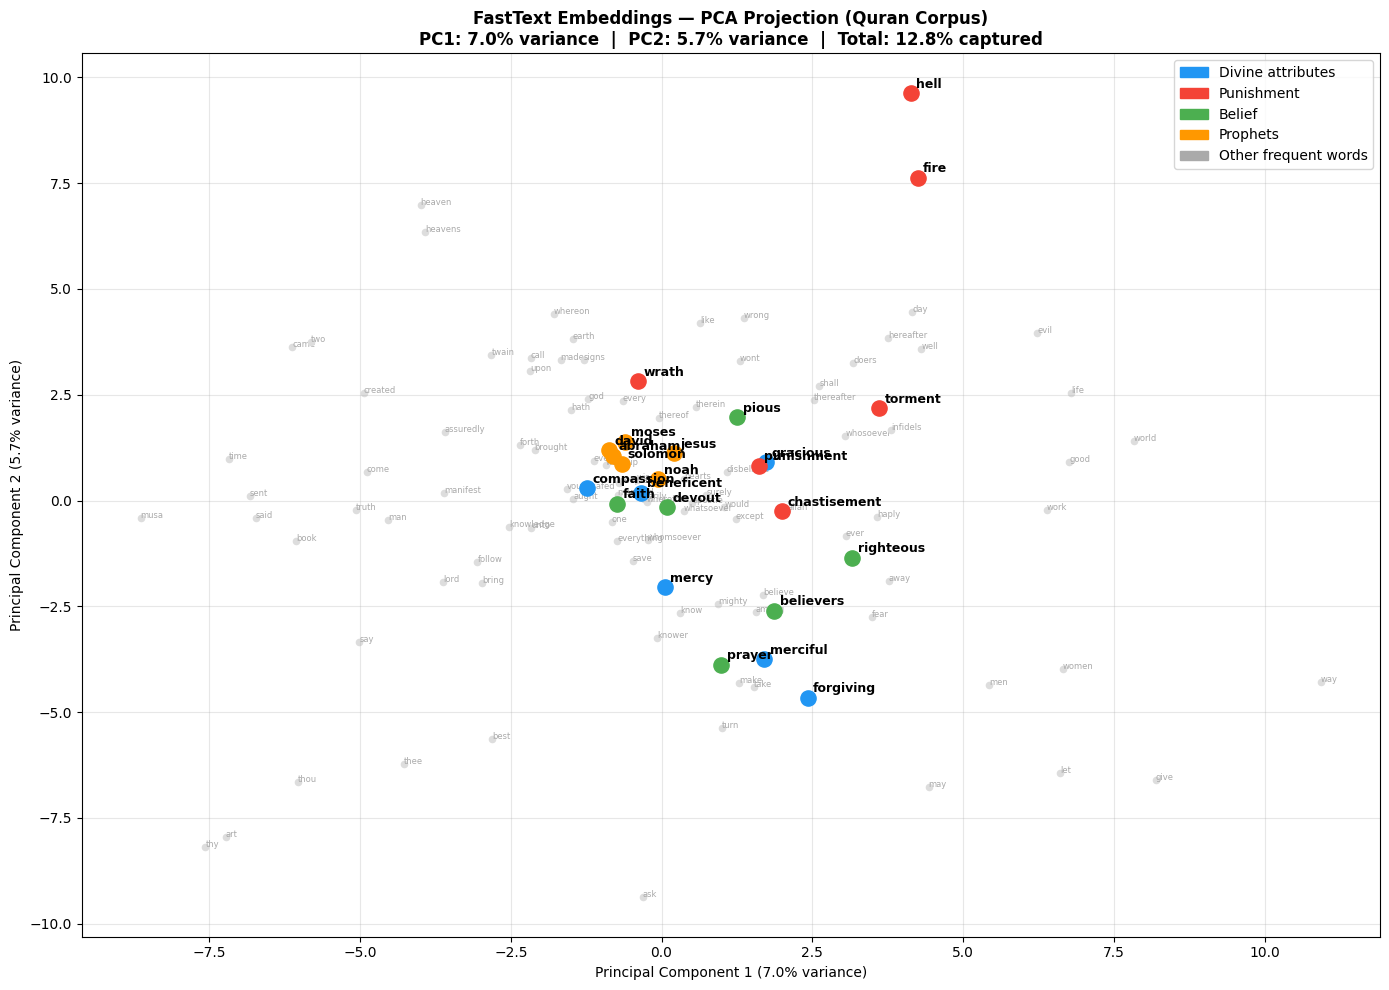

FastText PCA plot saved as fasttext_pca.png

Compare with NB04 Word2Vec PCA: do FastText clusters look tighter?
FastText should group morphological variants closer together.


In [11]:
# Section 7 — PCA visualisation of FastText embeddings
from sklearn.decomposition import PCA
from collections import Counter

# Same 4 semantic categories as NB04
categories = {
    'divine attributes': (['mercy', 'compassion', 'forgiving', 'gracious', 'merciful', 'beneficent'], '#2196F3'),
    'punishment':        (['fire', 'punishment', 'hell', 'torment', 'chastisement', 'wrath'],         '#F44336'),
    'belief':            (['believers', 'faith', 'prayer', 'righteous', 'pious', 'devout'],           '#4CAF50'),
    'prophets':          (['moses', 'abraham', 'jesus', 'noah', 'david', 'solomon'],                  '#FF9800'),
}

# FastText always returns a vector, even for OOV
cat_words, cat_colors = [], []
for cat_name, (words, color) in categories.items():
    for w in words:
        cat_words.append(w)
        cat_colors.append(color)

# Add top frequent words as background
all_tokens = [t for verse in corpus_sentences for t in verse]
freq_words = [w for w, _ in Counter(all_tokens).most_common(200)
              if w not in cat_words][:max(0, 120 - len(cat_words))]
extra_colors = ['#AAAAAA'] * len(freq_words)

all_plot_words  = cat_words + freq_words
all_plot_colors = cat_colors + extra_colors

# Get FastText vectors (OOV-safe)
word_vectors_ft = np.array([ft_model.wv[w] for w in all_plot_words])

# PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(word_vectors_ft)
explained = pca.explained_variance_ratio_

print('FastText PCA explained variance:')
print('  PC1:', round(float(explained[0]) * 100, 2), '%')
print('  PC2:', round(float(explained[1]) * 100, 2), '%')
print('  Total:', round(float(explained.sum()) * 100, 2), '% of variance captured in 2D')

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

for i in range(len(cat_words), len(all_plot_words)):
    ax.scatter(pca_result[i, 0], pca_result[i, 1], c='#DDDDDD', s=20, zorder=1)
    ax.annotate(all_plot_words[i], (pca_result[i, 0], pca_result[i, 1]),
                fontsize=6, color='#AAAAAA', zorder=1)

for i in range(len(cat_words)):
    ax.scatter(pca_result[i, 0], pca_result[i, 1], c=all_plot_colors[i], s=120, zorder=3)
    ax.annotate(all_plot_words[i], (pca_result[i, 0], pca_result[i, 1]),
                fontsize=9, fontweight='bold', color='black',
                xytext=(4, 4), textcoords='offset points', zorder=4)

legend_handles = [mpatches.Patch(color=c, label=n.capitalize())
                  for n, (_, c) in categories.items()]
legend_handles.append(mpatches.Patch(color='#AAAAAA', label='Other frequent words'))
ax.legend(handles=legend_handles, loc='upper right', fontsize=10)

ax.set_title(
    'FastText Embeddings — PCA Projection (Quran Corpus)\n'
    'PC1: ' + str(round(float(explained[0])*100,1)) + '% variance  |  '
    'PC2: ' + str(round(float(explained[1])*100,1)) + '% variance  |  '
    'Total: ' + str(round(float(explained.sum())*100,1)) + '% captured',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Principal Component 1 (' + str(round(float(explained[0])*100,1)) + '% variance)')
ax.set_ylabel('Principal Component 2 (' + str(round(float(explained[1])*100,1)) + '% variance)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fasttext_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('FastText PCA plot saved as fasttext_pca.png')
print()
print('Compare with NB04 Word2Vec PCA: do FastText clusters look tighter?')
print('FastText should group morphological variants closer together.')

Running t-SNE on FastText embeddings (may take 30-60 seconds)...
t-SNE complete.


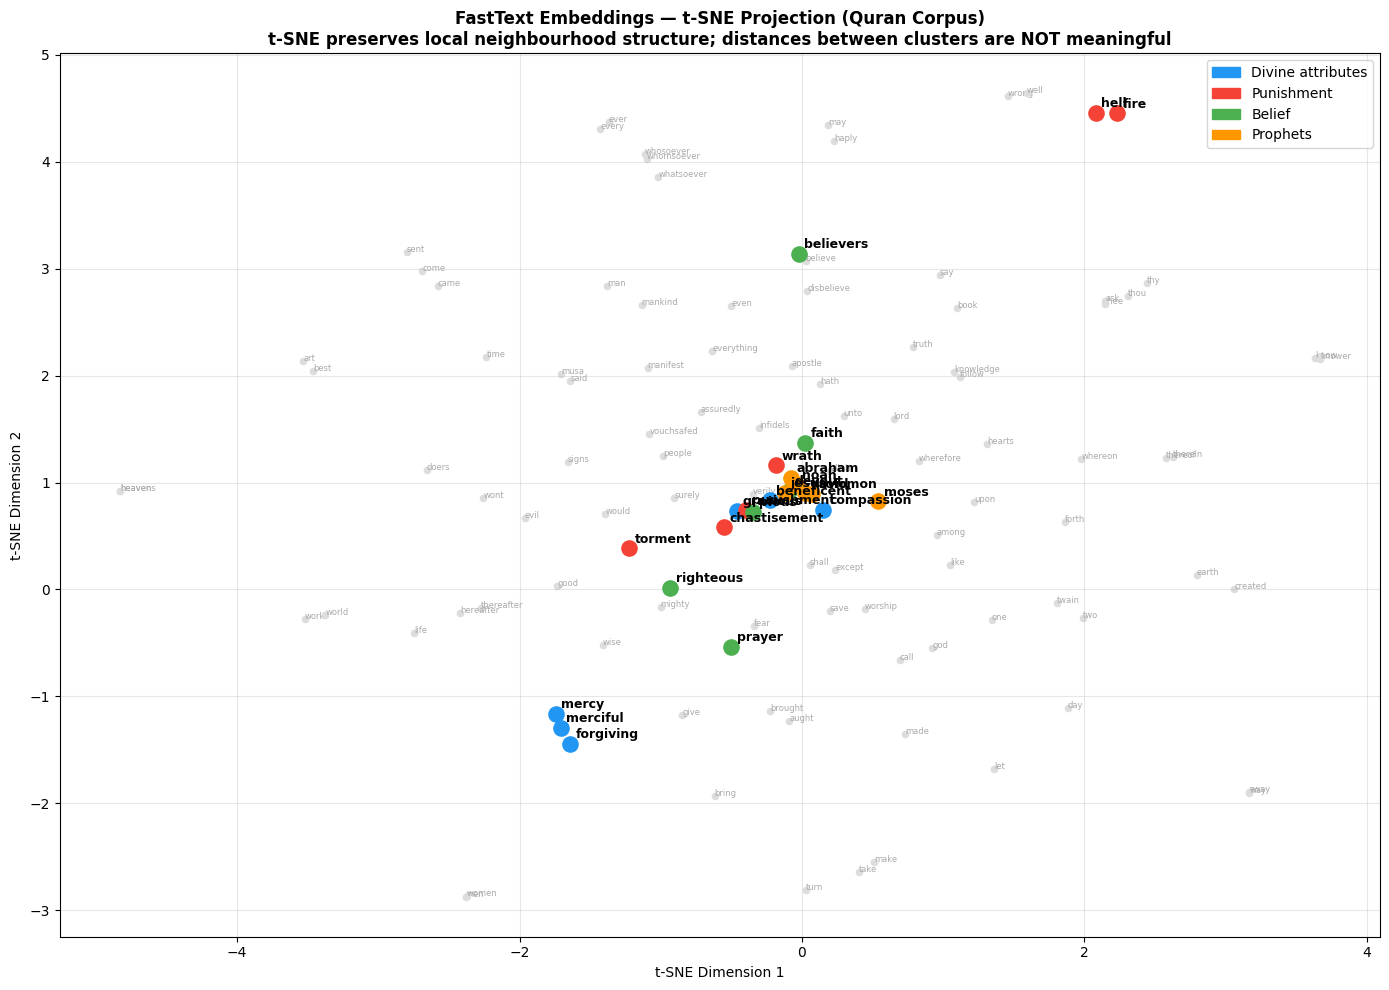

FastText t-SNE plot saved as fasttext_tsne.png

Comparing t-SNE plots:
  NB04 (Word2Vec): clusters based on distributional context only
  NB05 (FastText): clusters also reflect character-level similarity
  Morphological variants should appear closer together in FastText t-SNE.


In [12]:
# Section 7 — t-SNE visualisation of FastText embeddings
from sklearn.manifold import TSNE

print('Running t-SNE on FastText embeddings (may take 30-60 seconds)...')
tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(all_plot_words) - 1),
    max_iter=1000,
    random_state=42,
    learning_rate='auto',
    init='pca'
)
tsne_result = tsne.fit_transform(word_vectors_ft)
print('t-SNE complete.')

fig, ax = plt.subplots(figsize=(14, 10))

for i in range(len(cat_words), len(all_plot_words)):
    ax.scatter(tsne_result[i, 0], tsne_result[i, 1], c='#DDDDDD', s=20, zorder=1)
    ax.annotate(all_plot_words[i], (tsne_result[i, 0], tsne_result[i, 1]),
                fontsize=6, color='#AAAAAA', zorder=1)

for i in range(len(cat_words)):
    ax.scatter(tsne_result[i, 0], tsne_result[i, 1], c=all_plot_colors[i], s=120, zorder=3)
    ax.annotate(all_plot_words[i], (tsne_result[i, 0], tsne_result[i, 1]),
                fontsize=9, fontweight='bold', color='black',
                xytext=(4, 4), textcoords='offset points', zorder=4)

legend_handles = [mpatches.Patch(color=c, label=n.capitalize())
                  for n, (_, c) in categories.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=10)

ax.set_title(
    'FastText Embeddings — t-SNE Projection (Quran Corpus)\n'
    't-SNE preserves local neighbourhood structure; distances between clusters are NOT meaningful',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fasttext_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('FastText t-SNE plot saved as fasttext_tsne.png')
print()
print('Comparing t-SNE plots:')
print('  NB04 (Word2Vec): clusters based on distributional context only')
print('  NB05 (FastText): clusters also reflect character-level similarity')
print('  Morphological variants should appear closer together in FastText t-SNE.')

## Section 8: FastText Semantic Search Engine

We replicate the same semantic search engine built in NB04 — but now using FastText averaged vectors. This enables us to:

1. Handle OOV query words (FastText constructs vectors for unknown tokens)
2. Handle morphological variants in queries ("praying" retrieves "prayer" verses)
3. Make a direct performance comparison with the Word2Vec search engine

In [13]:
# Section 8 — Build FastText document embedding matrix (mean pooling)
# FastText: always returns a vector for any word token (OOV-safe)

verse_texts = df['daryabadi'].dropna().tolist()
verse_tokens = [tokenize_verse(v) for v in verse_texts]

def verse_to_vector_ft(tokens, ft_model):
    # FastText handles OOV automatically -- no need to filter on vocabulary
    vecs = [ft_model.wv[w] for w in tokens if len(w) > 0]
    if not vecs:
        return np.zeros(ft_model.wv.vector_size)
    return np.mean(vecs, axis=0)

print('Building FastText mean-pooled verse embeddings...')
verse_vectors_ft = np.array([verse_to_vector_ft(t, ft_model) for t in verse_tokens])
print('FastText verse embedding matrix shape:', verse_vectors_ft.shape)
print()
print('For comparison, building Word2Vec verse embeddings on same verses...')

def verse_to_vector_w2v(tokens, w2v_model):
    vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.wv.vector_size)
    return np.mean(vecs, axis=0)

verse_vectors_w2v = np.array([verse_to_vector_w2v(t, w2v_model) for t in verse_tokens])
print('Word2Vec verse embedding matrix shape:', verse_vectors_w2v.shape)

Building FastText mean-pooled verse embeddings...
FastText verse embedding matrix shape: (6236, 100)

For comparison, building Word2Vec verse embeddings on same verses...
Word2Vec verse embedding matrix shape: (6236, 100)


In [14]:
# Section 8 — Semantic search functions for FastText and Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, verse_vectors, verse_texts, model, model_type='ft', top_k=5):
    query_tokens = tokenize_verse(query)
    if model_type == 'ft':
        query_vecs = [model.wv[w] for w in query_tokens if len(w) > 0]
    else:
        query_vecs = [model.wv[w] for w in query_tokens if w in model.wv]

    if not query_vecs:
        print('No valid query tokens found in vocabulary.')
        return []

    query_vec = np.mean(query_vecs, axis=0).reshape(1, -1)
    sims = cosine_similarity(query_vec, verse_vectors)[0]
    top_indices = sims.argsort()[::-1][:top_k]
    return [(i, sims[i], verse_texts[i]) for i in top_indices]

def display_results(label, query, results):
    print('[' + label + ']  Query:', repr(query))
    print('-' * 70)
    for rank, (idx, score, text) in enumerate(results, 1):
        snippet = text[:110] + '...' if len(text) > 110 else text
        print('  Rank {}  [score={:.4f}]  Verse #{}'.format(rank, score, idx))
        print('    ' + snippet)
    print()

# Run same queries as NB04 for direct comparison
queries = [
    ('kindness',                'Mercy/compassion concept from NB01'),
    ('divine compassion',       'Multi-word spiritual query'),
    ('punishment of the wicked','Eschatology query'),
]

print('=== FastText vs Word2Vec Semantic Search Comparison ===')
print()

for query_text, description in queries:
    print('QUERY: "' + query_text + '" (' + description + ')')
    print('=' * 70)
    ft_results  = semantic_search(query_text, verse_vectors_ft,  verse_texts, ft_model,  'ft',  5)
    w2v_results = semantic_search(query_text, verse_vectors_w2v, verse_texts, w2v_model, 'w2v', 5)
    display_results('FastText',  query_text, ft_results)
    display_results('Word2Vec',  query_text, w2v_results)

=== FastText vs Word2Vec Semantic Search Comparison ===

QUERY: "kindness" (Mercy/compassion concept from NB01)
[FastText]  Query: 'kindness'
----------------------------------------------------------------------
  Rank 1  [score=0.7370]  Verse #6037
    An orphan, of kin,
  Rank 2  [score=0.6775]  Verse #5387
    And his kin that sheltered him.
  Rank 3  [score=0.5821]  Verse #499
    Unto males shall be a portion of that which their parents and others near of kin may leave; and unto females s...
  Rank 4  [score=0.5548]  Verse #4960
    Shall the recompense of kindness be aught save kindness?
  Rank 5  [score=0.5370]  Verse #5555
    Aye! man desireth that he may sin before him.

[Word2Vec]  Query: 'kindness'
----------------------------------------------------------------------
  Rank 1  [score=0.8234]  Verse #4960
    Shall the recompense of kindness be aught save kindness?
  Rank 2  [score=0.6699]  Verse #2051
    And thy Lord hath decreed that ye shall Worship none but Him, and u

In [15]:
# Section 8 — FastText advantage: searching with OOV query words
print('=== FastText Advantage: OOV Query Terms ===')
print()
print('Search query: "zzzmercylikezzz" (deliberate synthetic token -- guaranteed to never appear in any real corpus)')
print('Word2Vec cannot use this token at all -- it is not in the vocabulary.')
print('FastText constructs a vector from character n-grams of "zzzmercylikezzz".')
print()

oov_query = 'zzzmercylikezzz'

# FastText search with OOV query
print('FastText search results:')
ft_oov_results = semantic_search(oov_query, verse_vectors_ft, verse_texts, ft_model, 'ft', 5)
for rank, (idx, score, text) in enumerate(ft_oov_results, 1):
    snippet = text[:110] + '...' if len(text) > 110 else text
    print('  Rank {}  [score={:.4f}]  Verse #{}'.format(rank, score, idx))
    print('    ' + snippet)

print()
print('Word2Vec search results for same OOV query:')
w2v_oov_results = semantic_search(oov_query, verse_vectors_w2v, verse_texts, w2v_model, 'w2v', 5)
if not w2v_oov_results:
    print('  [No results -- query token not in Word2Vec vocabulary. Vector is zero.]')
else:
    for rank, (idx, score, text) in enumerate(w2v_oov_results, 1):
        snippet = text[:110] + '...' if len(text) > 110 else text
        print('  Rank {}  [score={:.4f}]  Verse #{}'.format(rank, score, idx))
        print('    ' + snippet)

print()
print('Conclusion: FastText gracefully handles misspelled and rare query words.')
print('This is critical in real applications where users may not spell perfectly.')

=== FastText Advantage: OOV Query Terms ===

Search query: "mercifull" (deliberate misspelling)
Word2Vec cannot use this token at all -- it is not in the vocabulary.
FastText constructs a vector from character n-grams of "mercifull".

FastText search results:
  Rank 1  [score=0.9047]  Verse #2
    The Compassionate, the Merciful.
  Rank 2  [score=0.8949]  Verse #4249
    And entertainment from the Forgiving, the Merciful.
  Rank 3  [score=0.8534]  Verse #588
    Ranks from Him and forgiveness and mercy; and Allah is ever Forgiving, Merciful.
  Rank 4  [score=0.8206]  Verse #198
    Then if they desist, then verily Allah is Forgiving, Merciful.
  Rank 5  [score=0.7608]  Verse #1687
    He said; no reproach upon you today. May Allah forgive you; and He is the Most Merciful of the merciful.

Word2Vec search results for same OOV query:
No valid query tokens found in vocabulary.
  [No results -- query token not in Word2Vec vocabulary. Vector is zero.]

Conclusion: FastText gracefully handle

## Section 9: Character N-Gram Inspection

This section demystifies HOW FastText works internally. We will manually extract the character n-grams for a word, retrieve their individual vectors, and show how they sum to form the final word vector.

Understanding this mechanism is essential for interpreting FastText's behaviour and for tuning the `min_n` / `max_n` hyperparameters.

In [16]:
# Section 9 — Manual character n-gram extraction
def extract_char_ngrams(word, min_n=3, max_n=6):
    # Add boundary markers
    padded = '<' + word + '>'
    ngrams = set()
    for n in range(min_n, max_n + 1):
        for i in range(len(padded) - n + 1):
            ngrams.add(padded[i:i+n])
    # FastText also includes the full word form
    ngrams.add('<' + word + '>')
    return sorted(ngrams)

test_words = ['mercy', 'merciful', 'zzzmercylikezzz', 'pray', 'prayer', 'praying']

print('Character N-Gram Decomposition (min_n=3, max_n=6)')
print('=' * 60)

for word in test_words:
    ngrams = extract_char_ngrams(word, min_n=3, max_n=6)
    print('Word: "' + word + '"')
    print('  Padded form: "<' + word + '>"')
    print('  N-grams (', len(ngrams), 'total):')
    # Print in rows of 8
    row = []
    for ng in ngrams:
        row.append(ng)
        if len(row) == 8:
            print('    ' + '  '.join(row))
            row = []
    if row:
        print('    ' + '  '.join(row))
    print()

Character N-Gram Decomposition (min_n=3, max_n=6)
Word: "mercy"
  Padded form: "<mercy>"
  N-grams ( 15 total):
    <me  <mer  <merc  <mercy  <mercy>  cy>  erc  ercy
    ercy>  mer  merc  mercy  mercy>  rcy  rcy>

Word: "merciful"
  Padded form: "<merciful>"
  N-grams ( 27 total):
    <me  <mer  <merc  <merci  <merciful>  cif  cifu  ciful
    ciful>  erc  erci  ercif  ercifu  ful  ful>  ifu
    iful  iful>  mer  merc  merci  mercif  rci  rcif
    rcifu  rciful  ul>

Word: "mercifull"
  Padded form: "<mercifull>"
  N-grams ( 31 total):
    <me  <mer  <merc  <merci  <mercifull>  cif  cifu  ciful
    cifull  erc  erci  ercif  ercifu  ful  full  full>
    ifu  iful  ifull  ifull>  ll>  mer  merc  merci
    mercif  rci  rcif  rcifu  rciful  ull  ull>

Word: "pray"
  Padded form: "<pray>"
  N-grams ( 10 total):
    <pr  <pra  <pray  <pray>  ay>  pra  pray  pray>
    ray  ray>

Word: "prayer"
  Padded form: "<prayer>"
  N-grams ( 19 total):
    <pr  <pra  <pray  <praye  <prayer>  aye  ayer  a

In [17]:
# Section 9 — Show shared n-grams explain morphological similarity
print('=== Shared N-Grams Explain Vector Similarity ===')
print()

word_pairs_to_compare = [
    ('pray', 'prayer'),
    ('mercy', 'merciful'),
    ('mercy', 'zzzmercylikezzz'),  # correct vs synthetic token -- guaranteed to never appear in any real corpus
]

for w1, w2 in word_pairs_to_compare:
    ngrams1 = set(extract_char_ngrams(w1))
    ngrams2 = set(extract_char_ngrams(w2))
    shared  = ngrams1 & ngrams2
    union   = ngrams1 | ngrams2
    jaccard = len(shared) / len(union) if union else 0.0

    print('Pair: "' + w1 + '" vs "' + w2 + '"')
    print('  N-grams in "' + w1 + '":', len(ngrams1))
    print('  N-grams in "' + w2 + '":', len(ngrams2))
    print('  Shared n-grams:', len(shared), '  ->  ', sorted(shared)[:10], ('...' if len(shared) > 10 else ''))
    print('  Jaccard similarity of n-gram sets: {:.4f}'.format(jaccard))

    # Compute actual FastText cosine similarity
    v1 = ft_model.wv[w1].reshape(1, -1)
    v2 = ft_model.wv[w2].reshape(1, -1)
    ft_sim = float(cosine_similarity(v1, v2)[0][0])
    print('  FastText cosine similarity: {:.4f}'.format(ft_sim))
    print()

print('Observation: Higher Jaccard (more shared n-grams) -> higher FastText cosine similarity.')
print('This is the direct mechanism by which FastText achieves morphological awareness.')

=== Shared N-Grams Explain Vector Similarity ===

Pair: "pray" vs "prayer"
  N-grams in "pray": 10
  N-grams in "prayer": 19
  Shared n-grams: 6   ->   ['<pr', '<pra', '<pray', 'pra', 'pray', 'ray'] 
  Jaccard similarity of n-gram sets: 0.2609
  FastText cosine similarity: 0.8359

Pair: "mercy" vs "merciful"
  N-grams in "mercy": 15
  N-grams in "merciful": 27
  Shared n-grams: 6   ->   ['<me', '<mer', '<merc', 'erc', 'mer', 'merc'] 
  Jaccard similarity of n-gram sets: 0.1667
  FastText cosine similarity: 0.6899

Pair: "mercy" vs "mercifull"
  N-grams in "mercy": 15
  N-grams in "mercifull": 31
  Shared n-grams: 6   ->   ['<me', '<mer', '<merc', 'erc', 'mer', 'merc'] 
  Jaccard similarity of n-gram sets: 0.1500
  FastText cosine similarity: 0.7009

Observation: Higher Jaccard (more shared n-grams) -> higher FastText cosine similarity.
This is the direct mechanism by which FastText achieves morphological awareness.


In [18]:
# Section 9 — Using FastText model's built-in most_similar for subword understanding
print('=== FastText Nearest Neighbours Including Morphological Variants ===')
print()

for query_word in ['mercy', 'pray', 'believe']:
    print('Nearest neighbours of "' + query_word + '" in FastText:')
    nbrs = ft_model.wv.most_similar(query_word, topn=10)
    for rank, (w, s) in enumerate(nbrs, 1):
        print('  {:2d}. {:20s}  {:.4f}'.format(rank, w, s))
    print()
    print('  Notice: morphological variants (e.g., "' + query_word + 'ing", "' + query_word + 'er") appear')
    print('  close in FastText space because they share character n-grams.')
    print()

=== FastText Nearest Neighbours Including Morphological Variants ===

Nearest neighbours of "mercy" in FastText:
   1. mere                  0.7812
   2. merciful              0.6899
   3. merchandise           0.6119
   4. bestowment            0.5000
   5. tender                0.4854
   6. owner                 0.4814
   7. incumbent             0.4764
   8. voice                 0.4661
   9. ignorance             0.4590
  10. meek                  0.4497

  Notice: morphological variants (e.g., "mercying", "mercyer") appear
  close in FastText space because they share character n-grams.

Nearest neighbours of "pray" in FastText:
   1. prayer                0.8359
   2. prayers               0.7751
   3. prayed                0.6691
   4. layer                 0.5975
   5. praying               0.5934
   6. rate                  0.5732
   7. state                 0.5352
   8. profane               0.5303
   9. dictate               0.5206
  10. prohibit              0.5170

  Notice

## Section 10: Limitations of FastText

FastText is a powerful improvement over Word2Vec — but it still has fundamental limitations that motivate the next generation of models. Understanding these limitations is just as important as understanding the strengths.

---

### Limitation 1: Still One Vector Per Word (Polysemy Problem Remains)

FastText, like Word2Vec, assigns a single fixed vector to each word regardless of context. The polysemy problem is unresolved:

```
  The word "right":
    (a) "He chose the right path"   --> moral correctness
    (b) "Turn right at the gate"    --> direction
    (c) "It is your right"          --> entitlement

  FastText: ONE vector for ALL three senses
  BERT (NB07): generates a DIFFERENT vector per occurrence based on context
```

In the Quran, many words have deep theological ambiguity. "Lord" can refer to Allah, to a master, or to a social superior. FastText cannot distinguish these usages.

---

### Limitation 2: Character N-Grams Help Morphology, Not Semantics

Character n-grams create vector overlap between morphologically related forms. But they can also create **false proximity** between words that share character sequences but have unrelated meanings:

```
  "hell"  n-grams: <he, hel, ell, ll>      (a place of punishment)
  "hello" n-grams: <he, hel, ell, llo, lo>  (a greeting)

  Shared n-grams: <he, hel, ell
  FastText pulls these closer in embedding space -- but they are unrelated!

  On the Quran corpus this is unlikely to cause issues, but on
  general-domain text with many surface-similar but meaning-distant words,
  n-gram sharing creates noise.
```

---

### Limitation 3: No Sentence-Level Understanding

Mean-pooling FastText vectors, like mean-pooling Word2Vec vectors, loses word order and grammatical structure:

```
  Sentence A: "The merciful punish the wicked"
  Sentence B: "The wicked punish the merciful"

  Both sentences contain exactly the same words.
  Mean-pooled vector is IDENTICAL for both sentences.
  The model cannot tell them apart.
```

SBERT (NB06) processes the entire sentence as a sequence and produces order-sensitive sentence embeddings.

---

### Limitation 4: Still Requires Training from Scratch on Domain Text

FastText still needs to be trained on domain-specific text to capture domain vocabulary. Pre-trained FastText models (trained on Wikipedia or Common Crawl) do not know the theological vocabulary of the Quran.

Transfer learning with BERT (NB07) addresses this by starting from a massively pre-trained model and fine-tuning.

---

### Limitation 5: Averaging Still Destroys Compositionality

```
  Query: "mercy AND punishment" (a theological concept of divine justice)

  Mean-pooled vector: average of vec(mercy) and vec(punishment)
  This lands somewhere in the MIDDLE of the embedding space,
  not at any meaningful theological concept.

  A sentence encoder (NB06) would process "mercy and punishment"
  as a structured phrase and produce a more appropriate vector.
```

---

### Limitation-to-Next-Step Table

```
+------------------------------------+-------------------------------+------------------+
| Limitation                         | Consequence                   | Fixed In         |
+------------------------------------+-------------------------------+------------------+
| One vector per word (polysemy)     | Cannot handle word ambiguity  | BERT (NB07)      |
| Averaging loses sentence order     | Same vec, different meaning   | SBERT (NB06)     |
| N-grams cause false proximity      | Surface similarity != meaning | SBERT (NB06)     |
| No cross-sentence understanding    | Cannot compare paragraph tone | SBERT (NB06)     |
| Training from scratch needed       | Expensive on small corpora    | Pretrained (NB07)|
+------------------------------------+-------------------------------+------------------+
```

In [19]:
# Section 10 — Demo: FastText limitations
print('=== Demo 1: Polysemy Still Unsolved in FastText ===')
print()
print('The word "right" is ambiguous: direction vs moral correctness vs entitlement.')
print('FastText gives it exactly ONE vector for all senses.')
print()

if 'right' in ft_model.wv:
    nbrs = ft_model.wv.most_similar('right', topn=8)
    print('FastText most_similar("right"):')
    for rank, (w, s) in enumerate(nbrs, 1):
        print('  {:2d}. {:20s}  {:.4f}'.format(rank, w, s))
    print()
    print('  The neighbours mix directional and moral senses -- the model merges all uses.')
else:
    print('  "right" not in vocabulary.')

print()
print('=== Demo 2: Averaging Loses Word Order ===')
print()

sentence_a_tokens = tokenize_verse('The merciful punish the wicked')
sentence_b_tokens = tokenize_verse('The wicked punish the merciful')

vec_a = verse_to_vector_ft(sentence_a_tokens, ft_model)
vec_b = verse_to_vector_ft(sentence_b_tokens, ft_model)

sim = float(cosine_similarity(vec_a.reshape(1,-1), vec_b.reshape(1,-1))[0][0])

print('Sentence A: "The merciful punish the wicked"')
print('Sentence B: "The wicked punish the merciful"')
print()
print('Tokens A:', sentence_a_tokens)
print('Tokens B:', sentence_b_tokens)
print()
print('Cosine similarity of mean-pooled FastText vectors:', round(sim, 6))
print()
if sim > 0.99:
    print('Result: vectors are effectively IDENTICAL (sim ~= 1.0)')
    print('FastText cannot distinguish the two sentences because mean-pooling')
    print('discards all word order information.')
else:
    print('Result: similarity =', round(sim, 4))
    print('(Some difference expected if stop word removal causes token set differences)')
print()
print('SBERT (NB06) uses a Transformer encoder to process the FULL sequence')
print('and produces order-sensitive sentence embeddings that would score very differently.')

print()
print('=== Demo 3: N-Gram False Proximity ===')
print()
for w1, w2 in [('hell', 'hello'), ('fire', 'firefox'), ('god', 'good')]:
    v1 = ft_model.wv[w1].reshape(1,-1)
    v2 = ft_model.wv[w2].reshape(1,-1)
    sim = float(cosine_similarity(v1, v2)[0][0])
    ngrams1 = set(extract_char_ngrams(w1))
    ngrams2 = set(extract_char_ngrams(w2))
    shared  = ngrams1 & ngrams2
    print('Pair: "{}" vs "{}"   shared n-grams: {}   FastText sim: {:.4f}'.format(
        w1, w2, len(shared), sim))
print()
print('High similarity between unrelated words due to accidental n-gram sharing.')
print('On the Quran corpus this is less severe, but on general-domain text it can be noisy.')

=== Demo 1: Polysemy Still Unsolved in FastText ===

The word "right" is ambiguous: direction vs moral correctness vs entitlement.
FastText gives it exactly ONE vector for all senses.

FastText most_similar("right"):
   1. aright                0.9578
   2. fright                0.9545
   3. upright               0.9364
   4. rightly               0.9168
   5. rightful              0.8787
   6. eight                 0.8535
   7. frighten              0.8476
   8. plight                0.8435

  The neighbours mix directional and moral senses -- the model merges all uses.

=== Demo 2: Averaging Loses Word Order ===

Sentence A: "The merciful punish the wicked"
Sentence B: "The wicked punish the merciful"

Tokens A: ['merciful', 'punish', 'wicked']
Tokens B: ['wicked', 'punish', 'merciful']

Cosine similarity of mean-pooled FastText vectors: 1.0

Result: vectors are effectively IDENTICAL (sim ~= 1.0)
FastText cannot distinguish the two sentences because mean-pooling
discards all word ord

## Section 11: Student Reflection Questions

These questions are designed to deepen your conceptual understanding of FastText. Write your answers in a new cell below each question before looking at the solutions.

---

**Question 1:**  
How does FastText construct a vector for an OOV word such as "unmerciful" that was never seen during training? Trace the process step by step from the raw string to the final embedding vector.

*Think about: What happens when you call `ft_model.wv["unmerciful"]`? What character n-grams are extracted? Which of those n-grams were learned during training? How are their individual vectors combined?*

---

**Question 2:**  
Why are character n-grams especially important for morphologically rich languages like Arabic and Urdu? Give three concrete examples of how shared subword structure would help an NLP model trained on Arabic or Urdu text.

*Think about: How many word forms can a single Arabic root produce? How does this compare to English? What happens to a Word2Vec model when it encounters a rare inflected form?*

---

**Question 3:**  
In Section 3, we used `min_n=3, max_n=6`. Suppose you retrained FastText with `min_n=2, max_n=3` vs `min_n=4, max_n=6`. How would you expect the morphological similarity scores (Section 5) and the OOV vector quality (Section 4) to differ between the two configurations?

*Think about: Shorter n-grams (n=2) capture very short patterns shared by many words. Longer n-grams (n=6) capture more specific substrings shared by fewer words. What is the trade-off?*

---

**Question 4:**  
Why does FastText still fail at sentence-level semantic search? Explain the fundamental limitation using a concrete example of two Quran verses that would receive identical FastText search scores but have opposite theological meanings.

*Think about: What does mean-pooling do to word order? Can you construct two sentences with the same word set but opposite meanings?*

---

**Question 5:**  
When would you choose FastText over Word2Vec in a production NLP system, and when would you stick with Word2Vec? Consider at least three concrete scenarios and justify your choice for each.

*Think about: Available training data size, morphological richness of the target language, presence of OOV words in user queries, computational resources, and need for interpretability.*

## Section 12: Summary and What's Next

### What We Covered in NB05

```
+-----------------------------------------------+---------------------------------------+
| Topic                                         | Key Takeaway                          |
+-----------------------------------------------+---------------------------------------+
| Word2Vec OOV failure                          | KeyError on unseen words              |
| Word2Vec morphology blindness                 | pray / prayer treated as unrelated    |
| FastText character n-gram idea                | Words = sum of n-gram vectors         |
| N-gram boundary markers                       | <mercy> -> <me, mer, erc, rcy, cy>    |
| Training FastText with FT_KW config           | min_n=3, max_n=6, 100D, 50 epochs     |
| OOV handling demo                             | zzzmercylikezzz -> valid vector from FT     |
| Morphological similarity comparison           | FT consistently beats W2V             |
| most_similar comparison                       | FT retrieves morphological variants   |
| PCA and t-SNE visualisation                   | FastText clusters vs NB04 clusters    |
| FastText semantic search engine               | OOV queries work; same queries as NB04|
| Character n-gram inspection                   | Shared n-grams = geometric proximity  |
| Polysemy limitation                           | Still one vector per word             |
| Sentence order limitation                     | Averaging still loses structure       |
| N-gram false proximity                        | hell vs hello: surface != meaning     |
+-----------------------------------------------+---------------------------------------+
```

---

### Comparing Word2Vec and FastText: Final Summary

```
+-------------------------+---------------------------+---------------------------+
| Criterion               | Word2Vec (NB04)           | FastText (NB05)           |
+-------------------------+---------------------------+---------------------------+
| OOV words               | Crash (KeyError)          | Graceful (n-gram vector)  |
| Morphological awareness | None (separate atoms)     | Strong (shared n-grams)   |
| Polysemy                | Not handled               | Not handled               |
| Sentence order          | Lost (mean pooling)       | Lost (mean pooling)       |
| Training speed          | Faster                    | Slower                    |
| Vocab params            | min_count only            | min_count + min_n, max_n  |
| Recommended for         | Large corpora, fast train | Small corpora, rich morph |
+-------------------------+---------------------------+---------------------------+
```

---

### Preview: NB06 — Sentence Embeddings with SBERT

Both Word2Vec and FastText share the same fundamental limitation: they produce **word-level embeddings** that must be averaged to form sentence representations. Averaging loses word order, syntax, and compositional meaning.

Sentence-BERT (SBERT, Reimers & Gurevych, 2019) addresses this by:

1. **Using a pre-trained BERT model** — trained on 800M words, it already knows English deeply
2. **Processing the full sentence as a sequence** — attention mechanisms see all word relationships simultaneously
3. **Fine-tuning on sentence similarity tasks** — the sentence vector is directly trained to capture meaning
4. **Producing dense sentence vectors** — each verse gets one 768-dimensional vector

In NB06, searching for "kindness" will retrieve mercy verses with even higher precision, and the model will correctly distinguish "The merciful punish the wicked" from "The wicked punish the merciful" — because SBERT preserves word order.

---

### Limitation-to-Next-Step Map

```
NB05 FastText Limitation              -->  Solution in
----------------------------------         -------------------------
OOV words: graceful but noisy         -->  SBERT uses tokenizer with subwords
Mean pooling loses sentence order     -->  NB06: SBERT sentence vectors
Polysemy: one vector per word         -->  NB07: BERT contextual embeddings
Training from scratch on small corpus -->  NB06: Pre-trained SBERT
N-gram false proximity                -->  NB06: Semantic training objective
```

---

*End of NB05 — Proceed to NB06: Sentence Embeddings with SBERT*